In [ ]:
from google.colab import files

uploaded = files.upload()

Saving train-test.csv to train-test.csv


In [ ]:
import pandas as pd

df = pd.read_csv("train-test.csv")

print("Dataset shape:", df.shape)

Dataset shape: (48000, 14)


In [ ]:
df.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


In [ ]:
df.isna().sum()

,0
load_id,0
pickup,0
delivery,0
pickup_lat,0
pickup_lon,0
delivery_lat,0
delivery_lon,0
distance,0
equipment,0
weight,300


In [ ]:
print("Duplicate load IDs:", df["load_id"].duplicated().sum())

print("\nUnique values:")
print("Pickup locations:", df["pickup"].nunique())
print("Delivery locations:", df["delivery"].nunique())
print("Equipment types:", df["equipment"].nunique())

print("\nDate range:")
print("From:", df["date"].min())
print("To:", df["date"].max())

print("\nTarget statistics:")
print(df["posted_rate"].describe())

Duplicate load IDs: 0

Unique values:
Pickup locations: 64
Delivery locations: 64
Equipment types: 3

Date range:
From: 2025-01-01
To: 2025-10-31

Target statistics:
count    48000.000000
mean      2373.980682
std       1486.493245
min         57.220000
25%       1251.555000
50%       2030.760000
75%       3330.750000
max      25533.000000
Name: posted_rate, dtype: float64


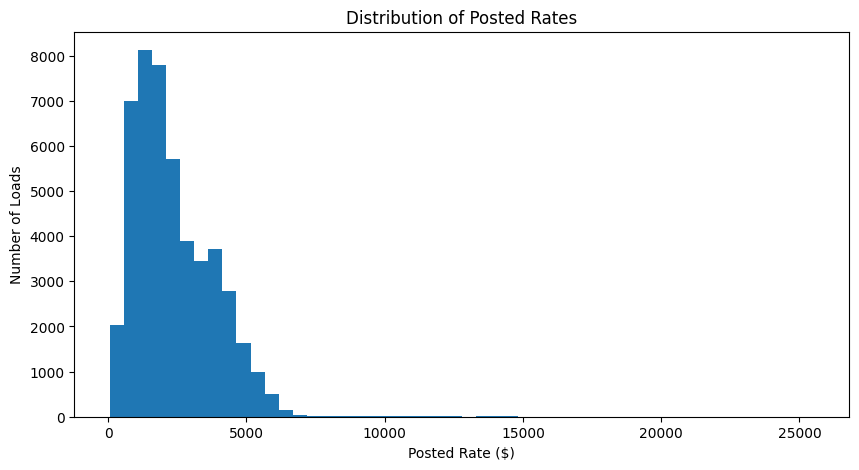

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(df["posted_rate"], bins=50)

plt.xlabel("Posted Rate ($)")
plt.ylabel("Number of Loads")
plt.title("Distribution of Posted Rates")

plt.show()

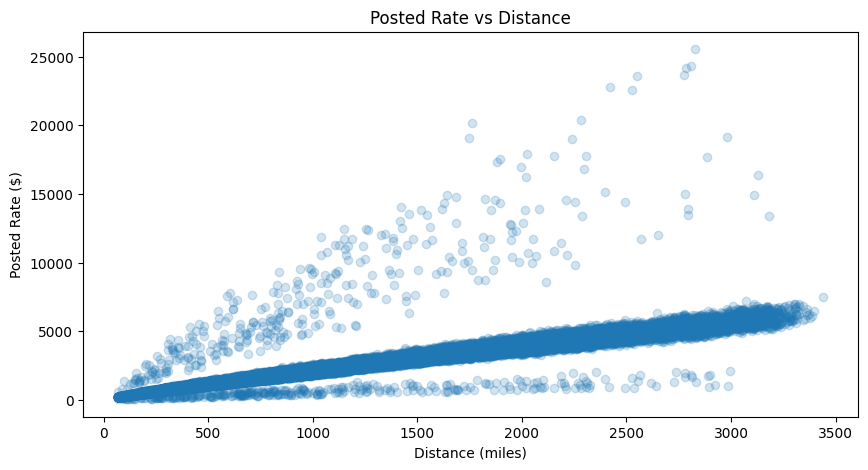

In [ ]:
plt.figure(figsize=(10, 5))

plt.scatter(
    df["distance"],
    df["posted_rate"],
    alpha=0.2
)

plt.xlabel("Distance (miles)")
plt.ylabel("Posted Rate ($)")
plt.title("Posted Rate vs Distance")

plt.show()

In [ ]:
df.groupby("equipment")["posted_rate"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

,count,mean,median,std,min,max
equipment,,,,,,
Dry Van,27202,2271.548686,1953.035,1423.029914,57.22,25533.00
Flatbed,8753,2445.087223,2076.810,1505.053087,157.76,17893.17
Reefer,12045,2553.636939,2196.670,1589.670824,63.36,24140.21


<Figure size 1000x600 with 0 Axes>

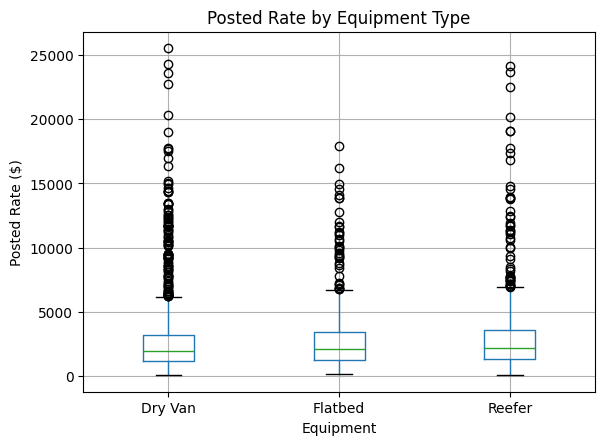

In [ ]:
plt.figure(figsize=(10, 6))

df.boxplot(
    column="posted_rate",
    by="equipment"
)

plt.title("Posted Rate by Equipment Type")
plt.suptitle("")
plt.xlabel("Equipment")
plt.ylabel("Posted Rate ($)")

plt.show()

In [ ]:
df.select_dtypes(include="number").corr()["posted_rate"].sort_values(ascending=False)

,posted_rate
posted_rate,1.000000
distance,0.908519
weight,0.034840
market_index,0.034165
quote_signal,-0.039858
pickup_lat,-0.090873
delivery_lat,-0.091970
pickup_lon,-0.255058
delivery_lon,-0.257086


In [ ]:
df["month"] = pd.to_datetime(df["date"]).dt.month

monthly_rate = (
    df.groupby("month")["posted_rate"]
      .agg(["mean", "median", "count"])
)

monthly_rate

,mean,median,count
month,,,
1,2255.967048,1915.200,4918
2,2273.804801,1994.250,4337
3,2372.268092,2022.920,5036
4,2372.162308,2044.240,4819
5,2421.776342,2065.510,4913
6,2497.030115,2120.220,4783
7,2415.162030,2059.145,4912
8,2338.407661,2015.730,4759
9,2406.374013,2057.130,4670


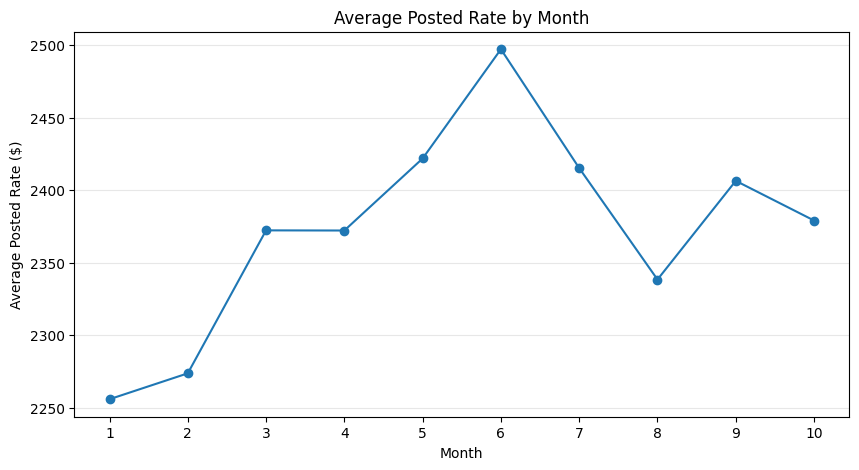

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_rate.index,
    monthly_rate["mean"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Average Posted Rate ($)")
plt.title("Average Posted Rate by Month")
plt.xticks(range(1, 11))

plt.grid(axis="y", alpha=0.3)
plt.show()

In [ ]:
print("Missing values:")
print(df[["weight", "market_index"]].isna().sum())

print("\nNon-positive values:")
print("Weight <= 0:", (df["weight"] <= 0).sum())
print("Distance <= 0:", (df["distance"] <= 0).sum())
print("Posted rate <= 0:", (df["posted_rate"] <= 0).sum())

Missing values:
weight          300
market_index    374
dtype: int64

Non-positive values:
Weight <= 0: 292
Distance <= 0: 0
Posted rate <= 0: 0


In [ ]:
df["weight"].describe()

,weight
count,47700.000000
mean,31028.844004
std,9391.440620
min,-47500.000000
25%,25800.000000
50%,31436.500000
75%,37018.000000
max,47500.000000


In [ ]:
df.loc[df["weight"] <= 0, ["weight", "distance", "equipment", "posted_rate"]].head(20)

,weight,distance,equipment,posted_rate
68,-36559.0,1334.2,Reefer,2831.27
204,-26670.0,496.2,Dry Van,1046.92
206,-20003.0,411.3,Reefer,959.15
225,-23981.0,1317.4,Reefer,2836.00
376,-41397.0,1331.1,Dry Van,2522.54
446,-37215.0,2438.3,Reefer,4841.57
495,-31214.0,715.9,Dry Van,1473.78
641,-41023.0,582.4,Dry Van,1264.33
806,-28320.0,676.1,Dry Van,1307.76
1093,-25153.0,1058.5,Dry Van,1907.83


In [ ]:
print("Weight == 0:", (df["weight"] == 0).sum())
print("Weight < 0:", (df["weight"] < 0).sum())

Weight == 0: 0
Weight < 0: 292


In [ ]:
import numpy as np

df_clean = df.copy()

# Treat negative weights as invalid/missing values
df_clean.loc[df_clean["weight"] < 0, "weight"] = np.nan

print("Missing weight after cleaning:", df_clean["weight"].isna().sum())
print("Missing market_index:", df_clean["market_index"].isna().sum())

Missing weight after cleaning: 592
Missing market_index: 374


In [ ]:
# Convert date from text to datetime
df_clean["date"] = pd.to_datetime(df_clean["date"])

# Use October as our internal validation period
cutoff = pd.Timestamp("2025-10-01")

train_df = df_clean[df_clean["date"] < cutoff].copy()
val_df = df_clean[df_clean["date"] >= cutoff].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)

print("\nTrain period:")
print(train_df["date"].min(), "to", train_df["date"].max())

print("\nValidation period:")
print(val_df["date"].min(), "to", val_df["date"].max())

Train shape: (43147, 15)
Validation shape: (4853, 15)

Train period:
2025-01-01 00:00:00 to 2025-09-30 00:00:00

Validation period:
2025-10-01 00:00:00 to 2025-10-31 00:00:00


In [ ]:
target = "posted_rate"

features = [
    "pickup",
    "delivery",
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "distance",
    "equipment",
    "weight",
    "date",
    "market_index",
    "quote_signal"
]

X_train = train_df[features].copy()
y_train = train_df[target].copy()

X_val = val_df[features].copy()
y_val = val_df[target].copy()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (43147, 12)
y_train: (43147,)
X_val: (4853, 12)
y_val: (4853,)


In [ ]:
print("Missing values in X_train:")
print(X_train.isna().sum())

print("\nMissing values in X_val:")
print(X_val.isna().sum())

Missing values in X_train:
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          527
date              0
market_index    332
quote_signal      0
dtype: int64

Missing values in X_val:
pickup           0
delivery         0
pickup_lat       0
pickup_lon       0
delivery_lat     0
delivery_lon     0
distance         0
equipment        0
weight          65
date             0
market_index    42
quote_signal     0
dtype: int64


In [ ]:
print("Training medians:")

print("weight median:", X_train["weight"].median())
print("market_index median:", X_train["market_index"].median())

Training medians:
weight median: 31492.0
market_index median: 1.08317


In [ ]:
# Calculate imputation values from training data only
weight_median = X_train["weight"].median()
market_median = X_train["market_index"].median()

# Apply the same values to both datasets
X_train["weight"] = X_train["weight"].fillna(weight_median)
X_val["weight"] = X_val["weight"].fillna(weight_median)

X_train["market_index"] = X_train["market_index"].fillna(market_median)
X_val["market_index"] = X_val["market_index"].fillna(market_median)

print("Remaining missing values in X_train:", X_train.isna().sum().sum())
print("Remaining missing values in X_val:", X_val.isna().sum().sum())

Remaining missing values in X_train: 0
Remaining missing values in X_val: 0


In [ ]:
def add_date_features(data):
    data = data.copy()

    data["date"] = pd.to_datetime(data["date"])

    data["month"] = data["date"].dt.month
    data["day_of_week"] = data["date"].dt.dayofweek
    data["day_of_month"] = data["date"].dt.day

    # We no longer need the raw date
    data = data.drop(columns=["date"])

    return data


X_train = add_date_features(X_train)
X_val = add_date_features(X_val)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

print("\nFeatures:")
print(X_train.columns.tolist())

X_train shape: (43147, 14)
X_val shape: (4853, 14)

Features:
['pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'market_index', 'quote_signal', 'month', 'day_of_week', 'day_of_month']


In [ ]:
!pip install -q catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.7 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostRegressor

categorical_features = [
    "pickup",
    "delivery",
    "equipment"
]

print("Categorical features:", categorical_features)

Categorical features: ['pickup', 'delivery', 'equipment']


In [ ]:
from catboost import CatBoostRegressor

baseline_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=7,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

baseline_model.fit(
    X_train,
    y_train,
    cat_features=categorical_features
)

0:	learn: 1422.8379769	total: 89.9ms	remaining: 44.8s
100:	learn: 582.1401657	total: 3.56s	remaining: 14s
200:	learn: 572.3464208	total: 7.1s	remaining: 10.6s
300:	learn: 565.6441321	total: 9.44s	remaining: 6.24s
400:	learn: 561.6344320	total: 11.8s	remaining: 2.91s
499:	learn: 555.9082309	total: 14.6s	remaining: 0us


CatBoostRegressor(depth=7, iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=100)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Predict October rates
val_predictions = baseline_model.predict(X_val)

# Calculate validation metrics
mae = mean_absolute_error(y_val, val_predictions)
rmse = mean_squared_error(y_val, val_predictions) ** 0.5

print(f"Validation MAE:  ${mae:,.2f}")
print(f"Validation RMSE: ${rmse:,.2f}")

Validation MAE:  $128.02
Validation RMSE: $651.49


In [ ]:
# Build a validation results table
val_results = val_df[
    ["load_id", "equipment", "distance", "posted_rate"]
].copy()

val_results["prediction"] = val_predictions

# Prediction error
val_results["error"] = (
    val_results["prediction"] - val_results["posted_rate"]
)

val_results["absolute_error"] = val_results["error"].abs()

print("Absolute error percentiles:")
print(
    val_results["absolute_error"].quantile(
        [0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

print("\nLargest absolute errors:")
print(
    val_results.sort_values("absolute_error", ascending=False)
    [["load_id", "equipment", "distance", "posted_rate",
      "prediction", "error", "absolute_error"]]
    .head(10)
)

Absolute error percentiles:
0.50      42.788238
0.75      81.530715
0.90     152.173796
0.95     242.332845
0.99    1832.751774
Name: absolute_error, dtype: float64

Largest absolute errors:
         load_id equipment  distance  posted_rate   prediction         error  \
43539  TR-043540   Dry Van    1893.0     17514.11  3766.712626 -13747.397374   
46213  TR-046214   Flatbed    2023.4     17893.17  4265.441331 -13627.728669   
47298  TR-047299    Reefer    2979.1     19110.30  5984.096971 -13126.203029   
46516  TR-046517    Reefer    1684.3     14784.38  3679.706037 -11104.673963   
46366  TR-046367   Dry Van    2251.9     14403.14  4375.031801 -10028.108199   
47536  TR-047537   Dry Van    2782.4     15003.55  5276.984070  -9726.565930   
43302  TR-043303    Reefer    2083.1     13894.55  4420.028904  -9474.521096   
44267  TR-044268   Dry Van    2492.6     14425.42  4967.720508  -9457.699492   
43384  TR-043385   Dry Van    1187.0     11696.44  2393.650796  -9302.789204   
47586  TR

In [ ]:
import numpy as np

print("Original target:")
print(y_train.describe())

print("\nLog-transformed target:")
print(np.log1p(y_train).describe())

Original target:
count    43147.000000
mean      2373.410351
std       1481.686233
min         57.220000
25%       1254.220000
50%       2029.700000
75%       3332.930000
max      25533.000000
Name: posted_rate, dtype: float64

Log-transformed target:
count    43147.000000
mean         7.573844
std          0.664823
min          4.064229
25%          7.135066
50%          7.616136
75%          8.111907
max         10.147766
Name: posted_rate, dtype: float64


In [ ]:
# Train CatBoost on log-transformed target
log_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=7,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

log_model.fit(
    X_train,
    np.log1p(y_train),
    cat_features=categorical_features
)

# Predict in log space, then convert back to dollar rates
log_val_predictions = log_model.predict(X_val)
log_val_predictions = np.expm1(log_val_predictions)

# Calculate validation metrics
log_mae = mean_absolute_error(y_val, log_val_predictions)
log_rmse = mean_squared_error(y_val, log_val_predictions) ** 0.5

print(f"\nLog-target Validation MAE:  ${log_mae:,.2f}")
print(f"Log-target Validation RMSE: ${log_rmse:,.2f}")

0:	learn: 0.6360001	total: 44.3ms	remaining: 22.1s
100:	learn: 0.1520962	total: 3.54s	remaining: 14s
200:	learn: 0.1503942	total: 7.01s	remaining: 10.4s
300:	learn: 0.1494138	total: 9.11s	remaining: 6.02s
400:	learn: 0.1485871	total: 11.5s	remaining: 2.83s
499:	learn: 0.1477439	total: 14.1s	remaining: 0us

Log-target Validation MAE:  $107.16
Log-target Validation RMSE: $649.03


In [ ]:
log_val_results = val_df[
    ["load_id", "equipment", "distance", "posted_rate"]
].copy()

log_val_results["prediction"] = log_val_predictions
log_val_results["absolute_error"] = (
    log_val_results["prediction"] - log_val_results["posted_rate"]
).abs()

print("Log-target absolute error percentiles:")
print(
    log_val_results["absolute_error"].quantile(
        [0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

print("\nLargest absolute errors:")
print(
    log_val_results
    .sort_values("absolute_error", ascending=False)
    [["load_id", "equipment", "distance", "posted_rate",
      "prediction", "absolute_error"]]
    .head(10)
)

Log-target absolute error percentiles:
0.50      33.753955
0.75      64.770382
0.90     112.877957
0.95     156.178625
0.99    1808.375216
Name: absolute_error, dtype: float64

Largest absolute errors:
         load_id equipment  distance  posted_rate   prediction  absolute_error
43539  TR-043540   Dry Van    1893.0     17514.11  3614.888249    13899.221751
46213  TR-046214   Flatbed    2023.4     17893.17  4248.328421    13644.841579
47298  TR-047299    Reefer    2979.1     19110.30  5929.105878    13181.194122
46516  TR-046517    Reefer    1684.3     14784.38  3561.087465    11223.292535
46366  TR-046367   Dry Van    2251.9     14403.14  4337.697243    10065.442757
47536  TR-047537   Dry Van    2782.4     15003.55  4962.887639    10040.662361
44267  TR-044268   Dry Van    2492.6     14425.42  4412.314106    10013.105894
43302  TR-043303    Reefer    2083.1     13894.55  4419.581000     9474.969000
43384  TR-043385   Dry Van    1187.0     11696.44  2382.766826     9313.673174
47586  T

In [ ]:
X_train["log_distance"] = np.log1p(X_train["distance"])
X_val["log_distance"] = np.log1p(X_val["distance"])

print(
    X_train[["distance", "log_distance"]].describe()
)

           distance  log_distance
count  43147.000000  43147.000000
mean    1136.967599      6.800873
std      728.275222      0.738070
min       70.000000      4.262680
25%      551.700000      6.314815
50%      954.700000      6.862444
75%     1647.900000      7.407864
max     3439.800000      8.143459


In [ ]:
log_distance_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=7,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

log_distance_model.fit(
    X_train,
    np.log1p(y_train),
    cat_features=categorical_features
)

# Predict and convert back to original dollar scale
log_distance_predictions = log_distance_model.predict(X_val)
log_distance_predictions = np.expm1(log_distance_predictions)

# Evaluate
log_distance_mae = mean_absolute_error(
    y_val, log_distance_predictions
)

log_distance_rmse = mean_squared_error(
    y_val, log_distance_predictions
) ** 0.5

print(f"\nLog-target + log-distance MAE:  ${log_distance_mae:,.2f}")
print(f"Log-target + log-distance RMSE: ${log_distance_rmse:,.2f}")

0:	learn: 0.6349540	total: 42.6ms	remaining: 21.2s
100:	learn: 0.1522453	total: 4.62s	remaining: 18.2s
200:	learn: 0.1504485	total: 7.11s	remaining: 10.6s
300:	learn: 0.1496346	total: 9.21s	remaining: 6.09s
400:	learn: 0.1487441	total: 11.9s	remaining: 2.93s
499:	learn: 0.1478540	total: 15.3s	remaining: 0us

Log-target + log-distance MAE:  $108.82
Log-target + log-distance RMSE: $648.21


In [ ]:
X_train_route = X_train.copy()
X_val_route = X_val.copy()

X_train_route["route"] = (
    X_train_route["pickup"] + " -> " + X_train_route["delivery"]
)

X_val_route["route"] = (
    X_val_route["pickup"] + " -> " + X_val_route["delivery"]
)

categorical_features_route = [
    "pickup",
    "delivery",
    "equipment",
    "route"
]

print("Number of unique training routes:", X_train_route["route"].nunique())
print("Number of unique validation routes:", X_val_route["route"].nunique())

Number of unique training routes: 4008
Number of unique validation routes: 2598


In [ ]:
route_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=7,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

route_model.fit(
    X_train_route,
    np.log1p(y_train),
    cat_features=categorical_features_route
)

route_predictions = route_model.predict(X_val_route)
route_predictions = np.expm1(route_predictions)

route_mae = mean_absolute_error(y_val, route_predictions)
route_rmse = mean_squared_error(y_val, route_predictions) ** 0.5

print(f"\nLog-target + route MAE:  ${route_mae:,.2f}")
print(f"Log-target + route RMSE: ${route_rmse:,.2f}")

0:	learn: 0.6357741	total: 52.4ms	remaining: 26.1s
100:	learn: 0.1523070	total: 5.99s	remaining: 23.7s
200:	learn: 0.1505236	total: 10.1s	remaining: 15s
300:	learn: 0.1496448	total: 12.9s	remaining: 8.52s
400:	learn: 0.1487042	total: 16.3s	remaining: 4.03s
499:	learn: 0.1477791	total: 20.7s	remaining: 0us

Log-target + route MAE:  $109.61
Log-target + route RMSE: $649.10


In [ ]:
final_candidate_model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.03,
    depth=7,
    loss_function="RMSE",
    random_seed=42,
    verbose=200
)

final_candidate_model.fit(
    X_train,
    np.log1p(y_train),
    cat_features=categorical_features,
    eval_set=(X_val, np.log1p(y_val)),
    use_best_model=True,
    early_stopping_rounds=100
)

candidate_predictions = final_candidate_model.predict(X_val)
candidate_predictions = np.expm1(candidate_predictions)

candidate_mae = mean_absolute_error(y_val, candidate_predictions)
candidate_rmse = mean_squared_error(y_val, candidate_predictions) ** 0.5

print(f"\nEarly-stopping model MAE:  ${candidate_mae:,.2f}")
print(f"Early-stopping model RMSE: ${candidate_rmse:,.2f}")
print("Best iteration:", final_candidate_model.get_best_iteration())

0:	learn: 0.6468798	test: 0.6634248	best: 0.6634248 (0)	total: 48.9ms	remaining: 1m 37s
200:	learn: 0.1515195	test: 0.1718138	best: 0.1718138 (199)	total: 8.15s	remaining: 1m 12s
400:	learn: 0.1500031	test: 0.1713291	best: 0.1713290 (398)	total: 12.7s	remaining: 50.5s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.1713097196
bestIteration = 419

Shrink model to first 420 iterations.

Early-stopping model MAE:  $108.68
Early-stopping model RMSE: $648.53
Best iteration: 419


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving validation.csv to validation.csv


In [ ]:
validation_df = pd.read_csv("validation.csv")

print("Validation shape:", validation_df.shape)
print(validation_df.head())

Validation shape: (12000, 13)
     load_id         pickup     delivery  pickup_lat  pickup_lon  \
0  TE-000001    Baton Rouge       Mobile    30.50134   -92.65374   
1  TE-000002       Savannah  Los Angeles    33.60973   -82.29994   
2  TE-000003  San Francisco      Raleigh    35.19670  -121.69849   
3  TE-000004         Dayton  Los Angeles    39.87206   -85.62931   
4  TE-000005        Memphis  San Antonio    35.56802   -89.52871   

   delivery_lat  delivery_lon  distance equipment   weight        date  \
0      31.80442     -88.25195     331.4   Flatbed  19958.0  2025-11-01   
1      28.56624    -116.70249    2406.2    Reefer  34114.0  2025-11-01   
2      35.37376     -77.47605    2846.6   Dry Van  33435.0  2025-11-01   
3      28.56624    -116.70249    2261.6   Dry Van  25392.0  2025-11-01   
4      29.50969     -98.40059     800.4   Flatbed      NaN  2025-11-01   

   market_index  quote_signal  
0       0.90402       1.86388  
1       0.92851       1.86240  
2       0.88117     

In [ ]:
# Start from the cleaned full training data
full_train = df_clean.copy()
final_validation = validation_df.copy()

# Make sure dates are datetime
full_train["date"] = pd.to_datetime(full_train["date"])
final_validation["date"] = pd.to_datetime(final_validation["date"])

# Features used by the selected model
features = [
    "pickup",
    "delivery",
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "distance",
    "equipment",
    "weight",
    "date",
    "market_index",
    "quote_signal"
]

X_full = full_train[features].copy()
y_full = full_train["posted_rate"].copy()

X_final_val = final_validation[features].copy()

# Impute using medians calculated from ALL labeled training data
weight_median_full = X_full["weight"].median()
market_median_full = X_full["market_index"].median()

X_full["weight"] = X_full["weight"].fillna(weight_median_full)
X_final_val["weight"] = X_final_val["weight"].fillna(weight_median_full)

X_full["market_index"] = X_full["market_index"].fillna(market_median_full)
X_final_val["market_index"] = X_final_val["market_index"].fillna(market_median_full)

# Date features
def add_date_features(data):
    data = data.copy()
    data["date"] = pd.to_datetime(data["date"])
    data["month"] = data["date"].dt.month
    data["day_of_week"] = data["date"].dt.dayofweek
    data["day_of_month"] = data["date"].dt.day
    data = data.drop(columns=["date"])
    return data

X_full = add_date_features(X_full)
X_final_val = add_date_features(X_final_val)

print("Final training shape:", X_full.shape)
print("Final validation shape:", X_final_val.shape)
print("\nRemaining missing values in training:", X_full.isna().sum().sum())
print("Remaining missing values in validation:", X_final_val.isna().sum().sum())

Final training shape: (48000, 14)
Final validation shape: (12000, 14)

Remaining missing values in training: 0
Remaining missing values in validation: 0


In [ ]:
final_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=7,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

final_model.fit(
    X_full,
    np.log1p(y_full),
    cat_features=categorical_features
)

print("\nFinal model training complete.")

0:	learn: 0.6367882	total: 42ms	remaining: 21s
100:	learn: 0.1542177	total: 3.63s	remaining: 14.3s
200:	learn: 0.1520195	total: 8.12s	remaining: 12.1s
300:	learn: 0.1508782	total: 11.4s	remaining: 7.54s
400:	learn: 0.1497958	total: 14.6s	remaining: 3.6s
499:	learn: 0.1488774	total: 18.7s	remaining: 0us

Final model training complete.


In [ ]:
# Predict on the 12,000 validation rows
validation_log_predictions = final_model.predict(X_final_val)

# Convert predictions back from log scale
validation_predictions = np.expm1(validation_log_predictions)

# Build the required submission file
submission = pd.DataFrame({
    "load_id": validation_df["load_id"],
    "predicted_rate": validation_predictions
})

print("Submission shape:", submission.shape)
print("\nFirst 5 predictions:")
print(submission.head())

print("\nPrediction summary:")
print(submission["predicted_rate"].describe())

print("\nMissing predictions:", submission["predicted_rate"].isna().sum())
print("Non-positive predictions:", (submission["predicted_rate"] <= 0).sum())

Submission shape: (12000, 2)

First 5 predictions:
     load_id  predicted_rate
0  TE-000001      840.639207
1  TE-000002     5006.066266
2  TE-000003     5244.084881
3  TE-000004     4063.257468
4  TE-000005     1873.024618

Prediction summary:
count    12000.000000
mean      2365.705405
std       1365.444380
min        206.909558
25%       1272.475164
50%       2047.032313
75%       3375.243882
max       6779.193110
Name: predicted_rate, dtype: float64

Missing predictions: 0
Non-positive predictions: 0


In [ ]:
submission.to_csv("validation_predictions.csv", index=False)

print("Saved: validation_predictions.csv")

# Verify the saved file
check = pd.read_csv("validation_predictions.csv")

print("Shape:", check.shape)
print("Columns:", list(check.columns))
print("First 5 rows:")
print(check.head())

Saved: validation_predictions.csv
Shape: (12000, 2)
Columns: ['load_id', 'predicted_rate']
First 5 rows:
     load_id  predicted_rate
0  TE-000001      840.639207
1  TE-000002     5006.066266
2  TE-000003     5244.084881
3  TE-000004     4063.257468
4  TE-000005     1873.024618


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving december-chart-inputs.csv to december-chart-inputs.csv


In [ ]:
december_df = pd.read_csv("december-chart-inputs.csv")

print("December shape:", december_df.shape)
print(december_df)

December shape: (31, 7)
       pickup    delivery  distance equipment  weight        date  \
0   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-01   
1   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-02   
2   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-03   
3   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-04   
4   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-05   
5   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-06   
6   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-07   
7   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-08   
8   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-09   
9   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-10   
10  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-11   
11  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-12   
12  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-13   
13  Lexing

In [ ]:
# Copy December inputs
december_features = december_df.copy()

# Get the route coordinates from the training data
route_info = full_train[
    (full_train["pickup"] == "Lexington") &
    (full_train["delivery"] == "Fort Wayne")
][[
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon"
]].drop_duplicates()

print("Matching Lexington -> Fort Wayne coordinate rows:")
print(route_info)

Matching Lexington -> Fort Wayne coordinate rows:
     pickup_lat  pickup_lon  delivery_lat  delivery_lon
654    36.99152   -84.99876      41.31561     -85.36206


In [ ]:
# Add the route coordinates
december_features["pickup_lat"] = route_info.iloc[0]["pickup_lat"]
december_features["pickup_lon"] = route_info.iloc[0]["pickup_lon"]
december_features["delivery_lat"] = route_info.iloc[0]["delivery_lat"]
december_features["delivery_lon"] = route_info.iloc[0]["delivery_lon"]

# December file does not provide these two fields,
# so use the medians learned from the full training data.
december_features["market_index"] = market_median_full
december_features["quote_signal"] = full_train["quote_signal"].median()

# Make sure date is datetime
december_features["date"] = pd.to_datetime(december_features["date"])

# Apply the exact same date feature engineering
december_features = add_date_features(december_features)

# Keep exactly the same feature columns and order used by the final model
december_features = december_features[
    X_full.columns
]

print("December feature shape:", december_features.shape)
print("\nColumns:")
print(list(december_features.columns))
print("\nMissing values:", december_features.isna().sum().sum())

December feature shape: (31, 14)

Columns:
['pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'market_index', 'quote_signal', 'month', 'day_of_week', 'day_of_month']

Missing values: 0


In [ ]:
# Predict December rates
december_log_predictions = final_model.predict(december_features)

# Convert back from log scale
december_predictions = np.expm1(december_log_predictions)

# Fill the required predicted_rate column
december_output = december_df.copy()
december_output["predicted_rate"] = december_predictions

print(december_output)

       pickup    delivery  distance equipment  weight        date  \
0   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-01   
1   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-02   
2   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-03   
3   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-04   
4   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-05   
5   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-06   
6   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-07   
7   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-08   
8   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-09   
9   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-10   
10  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-11   
11  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-12   
12  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-13   
13  Lexington  Fort Wayne       36

In [ ]:
december_output.to_csv("december_chart_inputs_with_predictions.csv", index=False)

print("Saved: december_chart_inputs_with_predictions.csv")
print("Shape:", december_output.shape)
print("Columns:", list(december_output.columns))

Saved: december_chart_inputs_with_predictions.csv
Shape: (31, 7)
Columns: ['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving score.py to score.py


In [ ]:
import shutil
import os

# Create the December file name expected by the scorer
shutil.copy(
    "december_chart_inputs_with_predictions.csv",
    "december_chart_inputs.csv"
)

print("Files ready:")
print(" -", os.path.exists("validation_predictions.csv"), "validation_predictions.csv")
print(" -", os.path.exists("december_chart_inputs.csv"), "december_chart_inputs.csv")
print(" -", os.path.exists("score.py"), "score.py")

Files ready:
 - True validation_predictions.csv
 - True december_chart_inputs.csv
 - True score.py


In [ ]:
!python score.py \
  --predictions validation_predictions.csv \
  --december-predictions december_chart_inputs.csv

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results/candidate_december.png
Final validation metrics are calculated by Spotter after submission.


In [ ]:
import pandas as pd
import numpy as np

# Load the final predictions
pred = pd.read_csv("validation_predictions.csv")

print("=== 1. Basic checks ===")
print("Shape:", pred.shape)
print("Columns:", list(pred.columns))
print("Missing values:")
print(pred.isna().sum())

print("\n=== 2. Prediction validity ===")
print("Non-positive predictions:", (pred["predicted_rate"] <= 0).sum())
print("Infinite predictions:", np.isinf(pred["predicted_rate"]).sum())
print("Unique load IDs:", pred["load_id"].nunique())

print("\n=== 3. Prediction distribution ===")
print(pred["predicted_rate"].describe())

print("\n=== 4. First 10 predictions ===")
print(pred.head(10))

# Check exact required IDs
expected_ids = [f"TE-{i:06d}" for i in range(1, 12001)]

print("\n=== 5. ID check ===")
print("IDs exactly correct:", pred["load_id"].tolist() == expected_ids)

# Check December file
dec = pd.read_csv("december_chart_inputs.csv")

print("\n=== 6. December checks ===")
print("Shape:", dec.shape)
print("Columns:", list(dec.columns))
print("Missing values:")
print(dec.isna().sum())
print("Non-positive predictions:", (dec["predicted_rate"] <= 0).sum())
print("Date range:", dec["date"].min(), "to", dec["date"].max())

print("\n=== CHECK COMPLETE ===")

=== 1. Basic checks ===
Shape: (12000, 2)
Columns: ['load_id', 'predicted_rate']
Missing values:
load_id           0
predicted_rate    0
dtype: int64

=== 2. Prediction validity ===
Non-positive predictions: 0
Infinite predictions: 0
Unique load IDs: 12000

=== 3. Prediction distribution ===
count    12000.000000
mean      2365.705405
std       1365.444380
min        206.909558
25%       1272.475164
50%       2047.032313
75%       3375.243882
max       6779.193110
Name: predicted_rate, dtype: float64

=== 4. First 10 predictions ===
     load_id  predicted_rate
0  TE-000001      840.639207
1  TE-000002     5006.066266
2  TE-000003     5244.084881
3  TE-000004     4063.257468
4  TE-000005     1873.024618
5  TE-000006     4315.714538
6  TE-000007     5287.752910
7  TE-000008     2790.891816
8  TE-000009     1077.798460
9  TE-000010     1118.793845

=== 5. ID check ===
IDs exactly correct: True

=== 6. December checks ===
Shape: (31, 7)
Columns: ['pickup', 'delivery', 'distance', 'equipme

In [ ]:
import pandas as pd

df = pd.read_csv("train-test.csv")

print(df.shape)
print(df.columns.tolist())
print(df["date"].min(), "to", df["date"].max())

(48000, 14)
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal', 'posted_rate']
2025-01-01 to 2025-10-31


In [ ]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load data
df = pd.read_csv("train-test.csv")
df["date"] = pd.to_datetime(df["date"])

# Clean negative weights exactly as before
df.loc[df["weight"] <= 0, "weight"] = np.nan

# Split by time
train_df = df[df["date"] < "2025-10-01"].copy()
oct_df = df[df["date"] >= "2025-10-01"].copy()

# Training-only medians
weight_median = train_df["weight"].median()
market_median = train_df["market_index"].median()

train_df["weight"] = train_df["weight"].fillna(weight_median)
oct_df["weight"] = oct_df["weight"].fillna(weight_median)

train_df["market_index"] = train_df["market_index"].fillna(market_median)
oct_df["market_index"] = oct_df["market_index"].fillna(market_median)

# Date features
def add_date_features(data):
    data = data.copy()
    data["month"] = data["date"].dt.month
    data["day_of_week"] = data["date"].dt.dayofweek
    data["day_of_month"] = data["date"].dt.day
    data = data.drop(columns=["date"])
    return data

train_df = add_date_features(train_df)
oct_df = add_date_features(oct_df)

# Features
features = [
    "pickup",
    "delivery",
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "distance",
    "equipment",
    "weight",
    "month",
    "day_of_week",
    "day_of_month",
    "market_index",
    "quote_signal"
]

categorical_features = ["pickup", "delivery", "equipment"]

X_train = train_df[features]
y_train = train_df["posted_rate"]

X_oct = oct_df[features]
y_oct = oct_df["posted_rate"]

# Train the same selected model
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=7,
    loss_function="RMSE",
    random_seed=42,
    verbose=False
)

model.fit(
    X_train,
    np.log1p(y_train),
    cat_features=categorical_features
)

# Predict October
oct_pred = np.expm1(model.predict(X_oct))

# Metrics
mae = mean_absolute_error(y_oct, oct_pred)
rmse = np.sqrt(mean_squared_error(y_oct, oct_pred))

print("=== October validation ===")
print("Training rows:", len(train_df))
print("October rows:", len(oct_df))
print()
print(f"MAE:  ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")

# Compare actual vs predicted
results = oct_df[["load_id", "posted_rate"]].copy()
results["predicted_rate"] = oct_pred
results["absolute_error"] = (
    results["predicted_rate"] - results["posted_rate"]
).abs()

print("\n=== Example predictions ===")
print(results.head(10).to_string(index=False))

print("\n=== Error distribution ===")
print(results["absolute_error"].describe())

=== October validation ===
Training rows: 43147
October rows: 4853

MAE:  $108.77
RMSE: $648.94

=== Example predictions ===
  load_id  posted_rate  predicted_rate  absolute_error
TR-043148      4001.45     4037.557762       36.107762
TR-043149      2466.25     2444.157702       22.092298
TR-043150      2526.28     2494.089353       32.190647
TR-043151      1518.22     1449.953606       68.266394
TR-043152      2999.76     3001.765142        2.005142
TR-043153      1704.26     1646.567039       57.692961
TR-043154       605.83      619.815398       13.985398
TR-043155      1176.88     1136.327952       40.552048
TR-043156      1900.80     1931.452632       30.652632
TR-043157      1914.59     1856.562280       58.027720

=== Error distribution ===
count     4853.000000
mean       108.774908
std        639.823823
min          0.001189
25%         15.957972
50%         35.840577
75%         66.990439
max      13949.975203
Name: absolute_error, dtype: float64
